In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from matplotlib import colors

In [2]:
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams.update({
  'font.size': 16, 
  'grid.alpha': 0.25})

In [69]:
def draw_percolates(percolates_data):
  ncols = len(percolates_data)
  figwidth = 2*ncols
  figheight = ncols

  fig, axes = plt.subplots(nrows=1, ncols=ncols, sharey=True, dpi=200, 
                            figsize=(figwidth, figheight))

  # create discrete colormap
  cmap = colors.ListedColormap(["w", "tab:blue", "k"])
  bounds = [0, 1, 2, 3]
  norm = colors.BoundaryNorm(bounds, cmap.N)

  if ncols > 1:
    for idx, data in enumerate(percolates_data):
      n = len(data)
      axes[idx].imshow(data, cmap=cmap, norm=norm, extent=[0, n, 0, n])

      axes[idx].grid(which="major", axis="both", linestyle="-", color="k", linewidth=1)
      axes[idx].set_xticks(np.arange(n+1))
      axes[idx].set_yticks(np.arange(n+1))
      axes[idx].tick_params(axis="x", which="major", bottom=False, labelbottom=False)
      axes[idx].tick_params(axis="y", which="major", left=False, labelleft=False)
  else:
    data = percolates_data[0].copy()
    print(data)
    m = len(data)
    n = len(data[0])
    print(m, n)
    axes.imshow(data, cmap=cmap, norm=norm, extent=[0, n, 0, m])

    axes.grid(which="major", axis="both", linestyle="-", color="k", linewidth=1)
    axes.set_xticks(np.arange(n+1))
    axes.set_yticks(np.arange(m+1))
    axes.tick_params(axis="x", which="major", bottom=False, labelbottom=False)
    axes.tick_params(axis="y", which="major", left=False, labelleft=False)

  return fig, axes

In [4]:
percolate_data = np.array(
  [[2, 2, 1, 1, 1, 2, 2, 2],
   [0, 2, 2, 1, 1, 1, 1, 1],
   [0, 0, 0, 2, 2, 1, 1, 2],
   [2, 2, 0, 0, 2, 1, 1, 1],
   [2, 0, 0, 0, 2, 1, 1, 2],
   [2, 0, 2, 2, 2, 2, 1, 1],
   [0, 2, 0, 2, 1, 1, 1, 1],
   [0, 0, 0, 0, 2, 1, 0, 0]])

non_percolate_data = np.array(
  [[2, 2, 1, 1, 2, 1, 2, 2],
   [1, 1, 1, 1, 1, 2, 2, 2],
   [1, 1, 2, 2, 1, 1, 2, 2], 
   [2, 2, 1, 1, 1, 1, 1, 2],
   [0, 2, 2, 2, 2, 2, 1, 1],
   [2, 0, 2, 0, 0, 0, 2, 2],
   [2, 0, 0, 2, 0, 0, 2, 0],
   [0, 2, 0, 2, 2, 2, 0, 2]
])

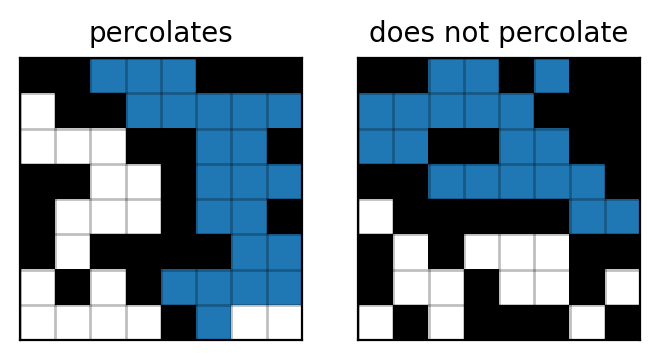

In [5]:
fig, axes = draw_percolates([percolate_data, non_percolate_data])

axes[0].set_title("percolates", fontsize=10)
axes[1].set_title("does not percolate", fontsize=10)

plt.show(fig)

In [6]:
vertically_percolates = np.array([
  [2, 2, 1, 1, 1, 2, 1],
  [0, 2, 2, 1, 1, 0, 1],
  [0, 0, 0, 2, 1, 0, 2],
  [2, 2, 0, 2, 1, 0, 0],
  [2, 0, 2, 2, 1, 0, 0],
  [0, 2, 0, 0, 1, 0, 0],
  [0, 0, 0, 2, 1, 2, 2]
])

not_vertically_percolates = np.array([
  [1, 2, 1, 1, 1, 2, 1],
  [1, 0, 1, 1, 2, 2, 1],
  [1, 0, 2, 1, 0, 2, 1],
  [2, 2, 0, 1, 0, 0, 1],
  [0, 2, 2, 2, 0, 0, 1],
  [2, 0, 0, 0, 0, 2, 2],
  [0, 2, 0, 2, 2, 0, 2]
])

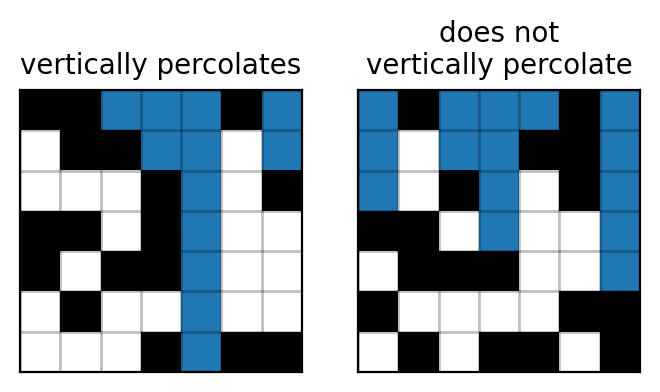

In [7]:
fig, axes = draw_percolates([vertically_percolates, not_vertically_percolates])

axes[0].set_title("vertically percolates", fontsize=10)
axes[1].set_title("does not\nvertically percolate", fontsize=10)

plt.show(fig)

Show only two rows

In [46]:
two_rows_percolation = [
  [1, 0, 2, 0, 1, 1, 0, 2, 1, 2],
  [2, 0, 0, 0, 2, 1, 2, 0, 1, 2] ]

[[1, 0, 2, 0, 1, 1, 0, 2, 1, 2], [2, 0, 0, 0, 2, 1, 2, 0, 1, 2]]
2 10


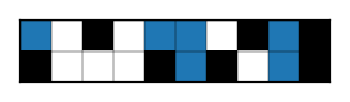

In [70]:
fig, ax = draw_percolates([two_rows_percolation])

plt.show(fig)

Generate several $n\times n$ sites with randomly blocked site locations

In [8]:
def bernoulli_trial(p, rng):
  out = 0
  if rng.random() < p:
    out = 1    # Success

  return out

In [9]:
def random_sites(n, p, rng=None):
  a = [[False for j in range(n)] for i in range(n)]
  for i in range(n):
    for j in range(n):
      a[i][j] = bernoulli_trial(p, rng)

  return a

In [10]:
def draw(a, which, ax, color="k"):
  n = len(a)

  for i in range(n):
    for j in range(n):
      if a[i][j] == which:
        rect = mpatches.Rectangle((j-0.5, (n-1-i)-0.5), 1, 1, facecolor=color, 
                                  edgecolor="w", linewidth=0.2)
        ax.add_artist(rect)

  return ax

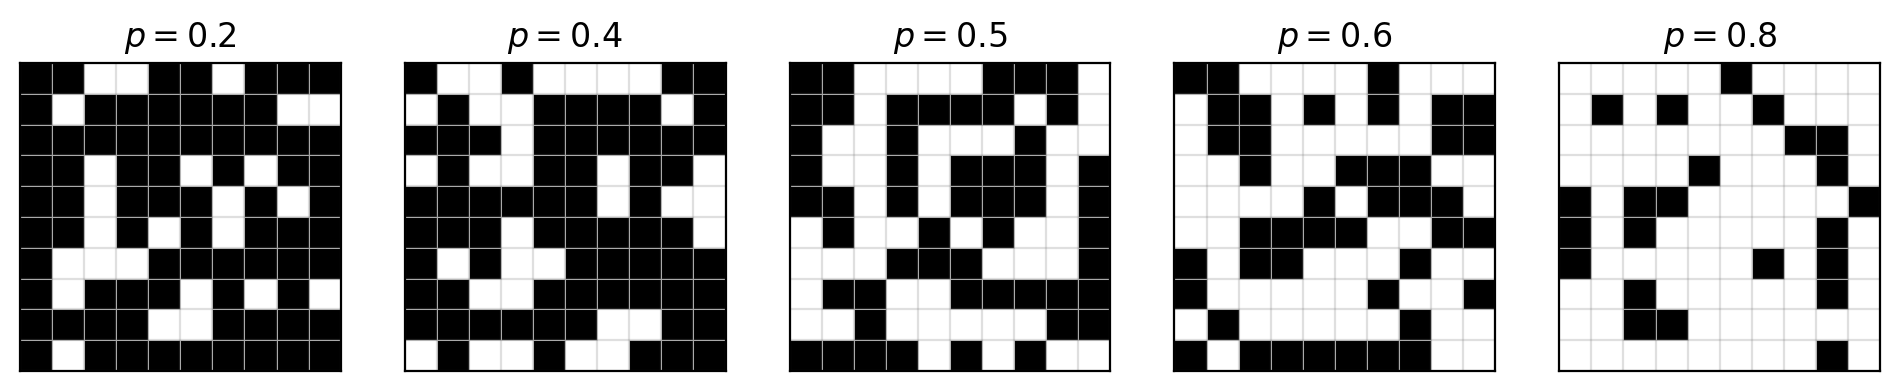

In [45]:
n = 10

seed = 26_04_29
rng = np.random.default_rng(seed)
p_arr = [0.2, 0.4, 0.5, 0.6, 0.8]

fig, axes = plt.subplots(ncols=5, nrows=1, figsize=(12, 2), dpi=200)

for idx, p in enumerate(p_arr):
  test = random_sites(n, p, rng=rng)
  axes[idx] = draw(test, False, axes[idx])

  # ax.grid(which="major", axis="both", linestyle="-", color="w", linewidth=1)
  axes[idx].set_xticks(np.arange(n+1)-0.5)
  axes[idx].set_yticks(np.arange(n+1)-0.5)
  axes[idx].tick_params(axis="x", which="major", top=False, labeltop=False, 
                        bottom=False, labelbottom=False), 
  axes[idx].tick_params(axis="y", which="major", left=False, labelleft=False)
  axes[idx].grid(color="gray")
  axes[idx].set_title(f"$p = ${p}", fontdict={"fontsize": 12})

plt.show(fig)